# Motor Imagery
- Ch2: C3
- Ch3: Cz
- Ch4: C4


In [128]:
# Bibliotheken & Konstanten
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.fft
import numpy as np

#PATH = "./data/gel juckt links/juckt-raw.csv"
#PATH = "./data/gel ohne oscar motor imagery nur rechts/mi-not-raw.csv"
PATH = "./data/gel ohne oscar motor imagery nur rechts/mi-raw.csv"
CHANNELS = {
    "EEG 1": "Fz",
    "EEG 2": "C3",
    "EEG 3": "Cz",
    "EEG 4": "C4",
    "EEG 5": "C4",
    "EEG 6": "PO7",
    "EEG 7": "Oz",
    "EEG 8": "PO8"
}
SAMPLE_FREQ = 250 #Hz


In [172]:
# Daten laden
# - unbrauchbare Daten am Anfang abschneiden

df = pd.read_csv(filepath_or_buffer= PATH,
                 sep = ',',
                 header=0,
                 usecols=[0,1,2,3,4,5,6,7,9]
                 #usecols=list(range(0, 8))   # ergibt [0, 1, 2, 3, 4, 5, 6, 7]
                 )

df = df.rename(columns= lambda x: x.strip())
print("Channels: ", df.columns.tolist())
print("Shape:    ", df.shape)

df_clean_start = df.drop(df.index[0:6000])

# schaue wann die Daten != 0 sind)
# Vektorisierung: Operation auf die gesamte Struktur gleichzeitig
# df[BEDINGUNG]
#df_clean_start = df[(df != 0).all(axis=1)]
print(df_clean_start)

Channels:  ['EEG 1', 'EEG 2', 'EEG 3', 'EEG 4', 'EEG 5', 'EEG 6', 'EEG 7', 'EEG 8', 'CNT']
Shape:     (37659, 9)
          EEG 1     EEG 2     EEG 3     EEG 4     EEG 5     EEG 6     EEG 7  \
6000   120746.9  195976.2  122695.5  217836.6  683993.9  170815.1  203880.2   
6001   120612.3  195789.8  122692.1  218343.0  684247.6  170363.0  203845.3   
6002   120569.0  195292.5  122681.8  218475.3  684232.6  169849.5  203703.3   
6003   120614.7  194933.5  122665.6  217901.4  683874.8  169803.6  203561.5   
6004   120736.5  195365.1  122669.9  217504.7  683767.3  170415.8  203672.0   
...         ...       ...       ...       ...       ...       ...       ...   
37654  121692.9  192095.7  123313.1  204029.8  684443.2  168645.2  195771.9   
37655  121762.4  191659.1  123306.7  203172.0  683806.6  168615.0  195555.5   
37656  121827.1  191907.6  123313.0  202863.5  683724.3  168951.8  195564.7   
37657  121753.9  192280.5  123329.4  203459.0  684076.0  169039.0  195727.3   
37658  121659.5  1

<Figure size 640x480 with 0 Axes>

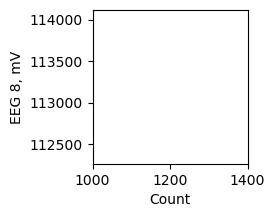

In [173]:
fig = plt.figure(  )
fig, ax = plt.subplots(figsize=( 2, 2))
ax.set_xlabel("Count")
ax.set_ylabel("EEG 8, mV")
ax.set_xlim(1000, 1400)
#ax.set_ylim(-50, 50)
ax.plot(df_clean_start["CNT"] , df_clean_start["EEG 8"], linewidth=0.5)
plt.show()

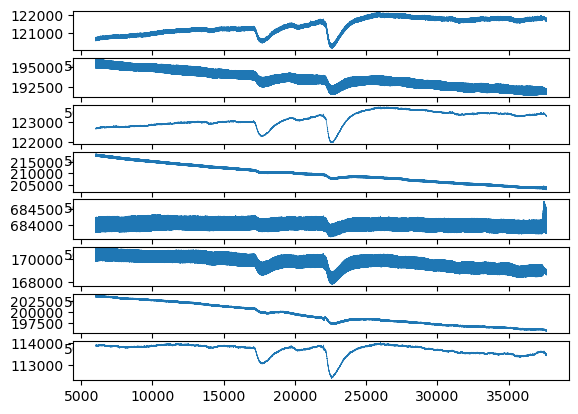

In [174]:
#mehrere Plots

fig_all, axs = plt.subplots(len(df.columns)-1)
for i in range(1, len(df.columns)):
    axs[i-1].plot (df_clean_start["CNT"] , df_clean_start[f"EEG {i}"], linewidth=0.5)


## DC-Offset + Bandpass + Notchfilter

In [260]:
# ------------------------ BANDPASSFILTER ANWENDEN
# Koeffizienten b (Zaehler) und a (Nennen) der Filter-Uebertragungsfunktion werden berechnet
b, a = signal.butter ( 4, [0.5, 40], fs=SAMPLE_FREQ, btype = "band",
                      output="ba")


# FIR/ IIR Filter auf die Daten anwenden
#df_bandfiltered = signal.lfilter (b, a, df_clean_start["EEG 4"])
print(df_clean_start.shape)
print(df_clean_start.columns)

#Filter wird nur auf EEG Kanaele angewendet, CNT schneide ich hier ab, deswegen -1
df_bandfiltered = np.zeros(shape=(df_clean_start.shape[0], df_clean_start.shape[1]-1))
print(len(df_clean_start.columns))
for i in range(1,len(df_clean_start.columns)):
    df_bandfiltered[:,i-1] = signal.lfilter (b,a, df_clean_start[f"EEG {i}"])
    print(i)


(31659, 9)
Index(['EEG 1', 'EEG 2', 'EEG 3', 'EEG 4', 'EEG 5', 'EEG 6', 'EEG 7', 'EEG 8',
       'CNT'],
      dtype='object')
9
1
2
3
4
5
6
7
8


1 Plot  0
2 Plot  1
3 Plot  2
4 Plot  3
5 Plot  4
6 Plot  5
7 Plot  6
8 Plot  7


(-200.0, 200.0)

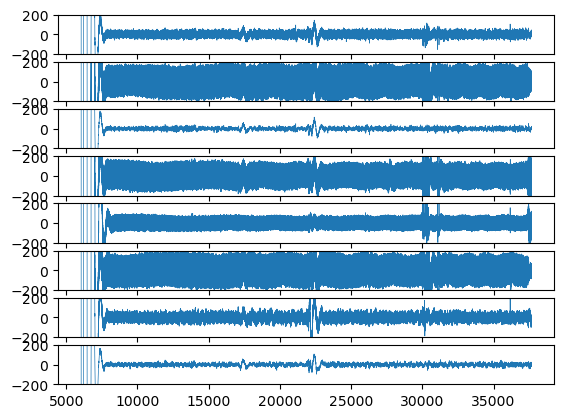

In [261]:
#Anzeigen nach Filtern
fig_all, axs = plt.subplots(len(df.columns)-1, sharex=True, sharey=True)

for i in range(1, len(df.columns)):
    axs[i-1].plot (df_clean_start["CNT"] , df_bandfiltered[:,i-1], linewidth=0.5)
    print(i, "Plot ", (i-1))
    
plt.ylim(-200,200)

(31659,)
EEG CHANNEK:  [ 4.30388495e+03  2.75672585e+04  8.11502803e+04 ...  1.06765395e+02
  2.37373411e+01 -8.83701646e+01]


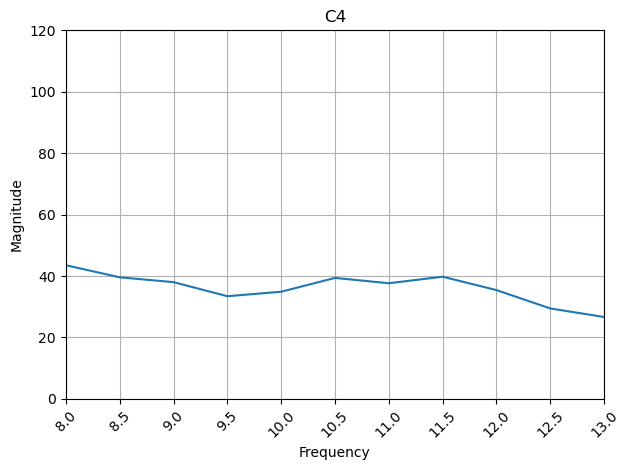

In [269]:
from scipy.fft import fft
import cmath #fuer komplexe zahlen

eeg_channel = df_bandfiltered[:,1]
print(eeg_channel.shape)
print("EEG CHANNEK: ", eeg_channel)
# ---------------------- SPEKTRUM VISUALISIEREN
# WINDOW SIZE: 500 Samples = 2 sec => 0.5Hz Unterschied erkennen
# input: df_bandfiltered (ES IST SCHON EEG 8.CHANNEL!)
windows_size = 500
n_windows = len(eeg_channel) // windows_size
df_truncated = eeg_channel[:n_windows*windows_size]

fft_average = np.zeros(shape=(windows_size,),
                            dtype="float64") #complex128
# WICHTIG: "apply a Hanning Window"
hann_window = signal.windows.hann(500)

for w in range(n_windows):
    #nimm w.te windows_size Datenpunkte
    window = df_truncated[w*windows_size : (w*windows_size + windows_size)]
    filtered_window = window * hann_window
    freq = np.fft.fft(filtered_window)

# magnitude: r = wurzel(real^2 + imaginaer^2)
# ODER abs(number, /)
# Return the absolute value of a number. ... If the argument is a complex number,
# its magnitude is returned.
    freq_squared = np.abs(freq) # magnitude 
    fft_average += freq_squared

fft_average = fft_average / windows_size # durchscnitt

frequencies = np.fft.fftfreq(500, 1/250)

# Keep only positive frequencies
positive_frequencies = frequencies[frequencies > 0]
#print(positive_frequencies)
positive_fft_values = fft_average[frequencies > 0]

# Plot
plt.plot(positive_frequencies, positive_fft_values)
plt.grid(visible=True)
plt.title("C4")
plt.xticks(np.arange(5, 15, 0.5), rotation=45)  # von 5 bis 30, Schrittweite 1
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.xlim(8,13)
plt.ylim(0,120)
plt.tight_layout()
plt.show()
# To get power, you square the magnitude. Power spectral density (PSD) plots show 
# power (magnitude squared) on the y-axis and frequency on the x-axis